# Function Encoding

This notebook shows how to encode a function ad a QTT using TTI. This method gives a constant time and constant error regardless the discretization


In [2]:
import torch as tn
import torchtt as tntt
import teneva as ten
import numpy as np
import matplotlib.pyplot as plt

%cd ..
from src.qtt_interpolation.utils import *

c:\Users\siddhartha.morales\OneDrive - Technology Innovation Institute\Documents\GitHub\QTT-polynomial-interpolation\ttinter\Lib\site-packages\torchtt\_dmrg.py:19: UserWarning: 
C++ implementation not available. Using pure Python.

  warnings.warn("\x1B\nC++ implementation not available. Using pure Python.\n\033")
c:\Users\siddhartha.morales\OneDrive - Technology Innovation Institute\Documents\GitHub\QTT-polynomial-interpolation\ttinter\Lib\site-packages\torchtt\_amen.py:21: UserWarning: 
C++ implementation not available. Using pure Python.

  warnings.warn(
c:\Users\siddhartha.morales\OneDrive - Technology Innovation Institute\Documents\GitHub\QTT-polynomial-interpolation\ttinter\Lib\site-packages\torchtt\solvers.py:21: UserWarning: 
C++ implementation not available. Using pure Python.

  warnings.warn(
c:\Users\siddhartha.morales\OneDrive - Technology Innovation Institute\Documents\GitHub\QTT-polynomial-interpolation\ttinter\Lib\site-packages\torchtt\cpp.py:12: UserWarning: 
C++ impl

c:\Users\siddhartha.morales\OneDrive - Technology Innovation Institute\Documents\GitHub\QTT-polynomial-interpolation


In [49]:
def ind_to_r(I, a=0, b=1, d=1, pdp=1):
    """
    This function maps a multi-digit index to a real number in [a, b)^d.
    Each entry in I[k] is an integer in 0,...,2**pdp-1 and is expanded to its binary representation.
    The resulting binary digits are concatenated to form a long vector of 0's and 1's for each sample.
    Returns a list of size d.
    """
    # I: shape (num_samples, d), each entry in 0,...,2**pdp-1
    num_samples = I.shape[0]
    l = I.shape[1] * pdp  # total number of binary digits per sample
    # Convert each entry to binary and concatenate
    I_bin = ((I.unsqueeze(-1) >> tn.arange(pdp-1, -1, -1)) & 1).reshape(num_samples, -1)
    powers = tn.tensor([2**(-i) for i in range(1, l//d+1)])
    result = []
    for j in range(d):
        idx = tn.arange(j, l, d)
        group = I_bin[:, idx]
        wI = group * powers
        x = (b - a) * wI.sum(axis=1) + a
        result.append(x)
    return result



def s4dnu(x, x0= 0.4, y0 = 0.5,s = 0.6, t = 0.25):

    xn = x/s - x0
    y = tn.where((xn >= 0) & (xn <= 1),y0 + 5*t*(0.2969*tn.sqrt(xn)-0.126*xn-0.3516*xn**2+0.2843*xn**3-0.1015*xn**4),-1)
    return y

def s4dnd(x, x0= 0.4, y0 = 0.5,s = 0.6, t = 0.25):

    xn = x/s - x0

    y = tn.where((xn >= 0) & (xn <= 1),y0-5*t*(0.2969*tn.sqrt(xn)-0.126*xn-0.3516*xn**2+0.2843*xn**3-0.1015*xn**4),-1)
    return y

def circle(x,y):
    """
    This function creates a mask for the points in the grid.
    It returns a boolean tensor where True indicates that the point is inside the unit square.
    """
    r=0.25
    return tn.where((x-0.5)**2 + (y-0.5)**2 <= r**2, 1, 0)

def correlated_gaussian_pdf(x, y, mean=None, corr=None):
    """
    Compute the PDF value of a 2D Gaussian at point (x, y) with given mean and correlation matrix.
    Args:
        x (float or torch.Tensor): x-coordinate(s)
        y (float or torch.Tensor): y-coordinate(s)
        mean (list or None): Mean of the distribution. If None, uses [0, 0].
        corr (2x2 torch.Tensor or None): Correlation matrix. If None, uses identity.
    Returns:
        torch.Tensor: PDF value(s) at (x, y)
    """
    if mean is None:
        mean = [0.0, 0.0]
    if corr is None:
        corr = tn.eye(2)
    pos = tn.stack([x, y], dim=-1)
    mean = tn.tensor(mean, dtype=pos.dtype, device=pos.device)
    corr_inv = tn.linalg.inv(corr)
    det_corr = tn.linalg.det(corr)
    diff = pos - mean
    exponent = -0.5 * tn.sum(diff @ corr_inv * diff, dim=-1)
    norm = 1.0 / (2 * np.pi * tn.sqrt(det_corr))
    return norm * tn.exp(exponent)

def circles(x,y):
    """
    This function creates a mask for the points in the grid.
    It returns a boolean tensor where True indicates that the point is inside the unit square.
    """
    r=0.25
    return tn.where((x-0.5)**2 + (y-0.5)**2 <= r**2, 1, tn.exp(-100*( (x-0.5)**2 + (y-0.5)**2 - r**2) ))

def wing(x,y):
    return tn.where( (s4dnu(x) >= y) & ( s4dnd(x) <= y), 1, 0)

In [41]:

base = 2
p = 13
N = [base,base]*p
mps = tntt.interpolate.dmrg_cross( lambda I: circles(*ind_to_r(I,d=2,pdp=1)) , N, eps = 1e-8,kick=1,rmax=30,nswp=30)
mps

TT with sizes and ranks:
N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
R = [1, 3, 5, 9, 17, 30, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 16, 8, 4, 2, 1]

Device: cpu, dtype: torch.float64
#entries 33474 compression 0.0004988014698028564

In [ ]:

base = 2
p = 8
N = [base**2]*p
mps = tntt.interpolate.dmrg_cross( lambda I: circles(*ind_to_r(I,d=2,pdp=2)) , N, eps = 1e-8,kick=4,rmax=300,nswp=30).round()
mps

TT with sizes and ranks:
N = [4, 4, 4, 4, 4, 4, 4, 4]
R = [1, 4, 16, 54, 75, 64, 16, 4, 1]

Device: cpu, dtype: torch.float64
#entries 43496 compression 0.6636962890625

In [ ]:
# Create a random 2D correlation matrix
A = tn.randn(2, 2)
cov = A @ A.t()  # Make it symmetric and positive definite
D = tn.diag(1 / tn.sqrt(tn.diag(cov)))
corr = D @ cov @ D  # Normalize to get correlation matrix



In [ ]:

base = 2
p = 11
N = [base**2]*p
mps = tntt.interpolate.dmrg_cross( lambda I: correlated_gaussian_pdf(*ind_to_r(I,a=-3,b=3,d=2,pdp=2),corr=corr,mean=[0,0]) , N, eps = 1e-10,kick=1,nswp=30).round()
mps

In [ ]:
ttmask = z_order_to_normal_torch(mps.full().flatten(), 2**p, 2**p).t().cpu().numpy()

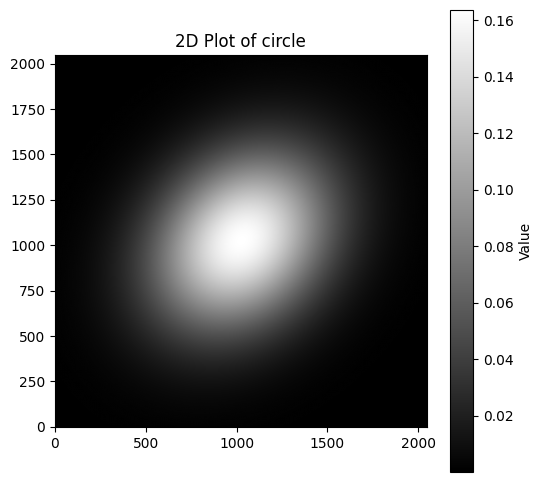

In [ ]:
plt.figure(figsize=(6, 6))
plt.imshow(ttmask, cmap='gray', origin='lower')
plt.colorbar(label='Value')
plt.title('2D Plot of circle')
plt.show()

## 2d Mask